# FX Pairs: Transaction-Cost Sensitivity

**Chapter 18 - Transaction Costs and Execution**

Trading friction consumes the selected allocation's small point estimate. The frozen validation
curve falls from Sharpe 0.324 without costs to 0.037 at the configured 7 bps per leg, then crosses
zero near 7.91 bps. Even the zero-cost confidence interval spans zero, so the curve measures cost
exposure rather than establishing a dependable edge.

1. **Reproduction contract** - analyze the registry without writing by default
2. **Cost sweep** - optionally apply the declared 11-point grid to the selected 21-day lineage
3. **Execution evidence** - locate breakeven and compare it with configured FX spread bands

**Book Reference:** Chapter 18, Sections 18.2-18.5

**Prerequisites:** Completed Ch17 allocation results in `registry.db`.

In [1]:
"""Ch18 transaction-cost sensitivity for the FX pairs case study."""

import json
import sqlite3
import time
from collections import defaultdict
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import (
    clone_backtest_spec,
    ensure_backtest_spec,
    serializable_backtest_spec,
    set_backtest_costs_bps,
    strategy_view,
)
from case_studies.utils.backtest_runner import normalize_prediction_columns, run_backtest
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    load_existing_backtest_hashes,
    read_predictions,
    resolve_best_backtest_runs,
)
from case_studies.utils.sweep_config import get_cost_grid_bps, get_top_n_predictions
from utils.paths import get_case_study_dir
from utils.style import COLORS

In [2]:
CASE_STUDY_ID = "fx_pairs"
LABEL = "fwd_ret_21d"
SPLIT = "validation"
MAX_SYMBOLS = 0
TOP_N_COMBOS = None
RUN_SWEEP = False
FORCE_REBACKTEST = False

## 1. The default path is read-only

The cost curve uses validation predictions, next-bar-open execution, and the selected 21-day
Ridge/HRP top-5 allocation. The 2024-2025 holdout remains outside this decision.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
REGISTRY_PATH = CASE_DIR / "run_log" / "registry.db"
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_COMBOS is None:
    TOP_N_COMBOS = get_top_n_predictions(CASE_STUDY_ID, "cost_sensitivity")
COST_GRID_BPS = get_cost_grid_bps(CASE_STUDY_ID)

print(f"""=== Protocol Term Sheet ===
  Case study:    {CASE_STUDY_ID}
  Label:         {LABEL}
  Split:         {SPLIT}
  Calendar:      {bt_config.calendar}
  Cadence:       {bt_config.cadence}
  Execution:     {bt_config.execution_delay}
  Cost grid:     {COST_GRID_BPS}
  Registry mode: {"write enabled" if RUN_SWEEP else "read only"}
""")

=== Protocol Term Sheet ===
  Case study:    fx_pairs
  Label:         fwd_ret_21d
  Split:         validation
  Calendar:      FX
  Cadence:       daily_ny_close
  Execution:     next_bar_open
  Cost grid:     [0.0, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0, 50.0]
  Registry mode: read only



In [4]:
top_combos = resolve_best_backtest_runs(
    CASE_STUDY_ID,
    LABEL,
    split=SPLIT,
    stage="allocation",
    top_n=TOP_N_COMBOS,
)
if top_combos.is_empty():
    raise RuntimeError("No validation allocation result found for the 21-day label")

for row in top_combos.iter_rows(named=True):
    allocation = strategy_view(json.loads(row["spec_json"]))["allocation"]
    print(
        f"Selected allocation: {allocation['method']} top-{allocation['top_k']} "
        f"Sharpe={row['sharpe']:.3f} hash={row['backtest_hash']}"
    )

Selected allocation: hrp top-5 Sharpe=0.037 hash=e1ac43ef7f7a


In [5]:
prices = load_backtest_prices_for(
    CASE_STUDY_ID,
    LABEL,
    split=SPLIT,
    warmup_periods=warmup_periods_for(CASE_STUDY_ID),
    max_symbols=MAX_SYMBOLS,
)
validation_end = prices["timestamp"].max()
if isinstance(validation_end, datetime):
    validation_end = validation_end.date()
holdout_start = datetime.fromisoformat(bt_config.holdout_start).date()
assert validation_end < holdout_start
print(f"Prices: {len(prices):,} rows, {prices['symbol'].n_unique()} pairs")
print(f"Validation ends {validation_end}; sealed holdout starts {holdout_start}")

Prices: 42,580 rows, 20 pairs
Validation ends 2023-12-29; sealed holdout starts 2024-01-01


## 2. The optional sweep applies the declared cost grid

Each grid point holds predictions, selection, allocation, and execution timing fixed. Total cost
is split equally between commission and slippage so only the total-bps axis changes. The configured
production mix is 5 bps commission plus 2 bps slippage; at the shared 7 bps total, the two mixes
differ by less than three millionths of a Sharpe unit in the frozen registry.

In [6]:
def _build_sweep_jobs() -> list[dict]:
    jobs = []
    for combo in top_combos.iter_rows(named=True):
        prediction_hash = combo["prediction_hash"]
        base_spec = ensure_backtest_spec(
            CASE_STUDY_ID,
            bt_config,
            json.loads(combo["spec_json"]),
            prices=prices,
            prediction_hash=prediction_hash,
            initial_cash=bt_config.initial_cash,
        )
        allocation = strategy_view(base_spec)["allocation"]["method"]
        for cost_bps in COST_GRID_BPS:
            spec = set_backtest_costs_bps(
                clone_backtest_spec(base_spec),
                commission_bps=cost_bps / 2,
                slippage_bps=cost_bps / 2,
            )
            spec["chapter"] = "ch18"
            jobs.append(
                {
                    "prediction_hash": prediction_hash,
                    "allocation": allocation,
                    "cost_bps": float(cost_bps),
                    "spec": spec,
                    "hash": backtest_hash_from_parts(
                        prediction_hash, serializable_backtest_spec(spec)
                    ),
                }
            )
    return jobs


sweep_jobs = _build_sweep_jobs()
print(f"Cost grid: {len(sweep_jobs)} backtests")

Cost grid: 11 backtests


In [7]:
existing_hashes = load_existing_backtest_hashes(CASE_STUDY_ID, stage="cost_sensitivity")
expected_hashes = {job["hash"] for job in sweep_jobs}
portable_overlap = expected_hashes & existing_hashes
print(f"Stored cost-sensitivity hashes: {len(existing_hashes)}")
print(f"Current-grid portable-hash overlap: {len(portable_overlap)}/{len(expected_hashes)}")

if RUN_SWEEP and existing_hashes and not portable_overlap:
    raise RuntimeError(
        "RUN_SWEEP refused: this registry uses legacy hashes. Migrate it or use a fresh registry."
    )
if not RUN_SWEEP:
    print("Reproduce-only mode: no backtests or registry rows will be written.")

Stored cost-sensitivity hashes: 33
Current-grid portable-hash overlap: 0/11
Reproduce-only mode: no backtests or registry rows will be written.


In [8]:
def _run_job(job: dict, predictions: pl.DataFrame) -> dict:
    result = run_backtest(
        CASE_STUDY_ID,
        job["prediction_hash"],
        job["spec"],
        prices=prices,
        predictions=predictions,
        label=LABEL,
        register=True,
        force_rebacktest=FORCE_REBACKTEST,
        initial_cash=bt_config.initial_cash,
        calendar=bt_config.calendar,
    )
    return {
        "backtest_hash": result.backtest_hash,
        "prediction_hash": job["prediction_hash"],
        "allocator": job["allocation"],
        "cost_bps": job["cost_bps"],
        "sharpe": result.metrics.get("sharpe"),
    }

In [9]:
sweep_results = []
if RUN_SWEEP:
    pending = [job for job in sweep_jobs if FORCE_REBACKTEST or job["hash"] not in existing_hashes]
    grouped = defaultdict(list)
    for job in pending:
        grouped[job["prediction_hash"]].append(job)
    started = time.time()
    completed = failed = 0
    for prediction_hash, jobs in grouped.items():
        predictions = normalize_prediction_columns(read_predictions(CASE_STUDY_ID, prediction_hash))
        for job in jobs:
            try:
                sweep_results.append(_run_job(job, predictions))
                completed += 1
            except Exception as exc:
                failed += 1
                stamp = datetime.now(UTC).isoformat(timespec="seconds")
                print(f"[{stamp}] FAILED {job['hash']}: {type(exc).__name__}: {exc}")
            processed = completed + failed
            if processed % 5 == 0 or processed == len(pending):
                stamp = datetime.now(UTC).isoformat(timespec="seconds")
                print(f"[{stamp}] completed={completed} failed={failed} total={len(pending)}")
    print(f"Sweep elapsed: {time.time() - started:.1f}s")
    if failed:
        raise RuntimeError(f"Cost sweep finished with {failed} failed backtests")

## 3. Costs erase the point estimate near 8 bps

The frozen registry contains one 11-point cost curve for each label. The analysis below pins the
21-day prediction chosen by Ch17, so the three horizon-specific curves cannot be pooled.

In [10]:
COST_SQL = """
SELECT br.backtest_hash, br.prediction_hash,
       tr.family, tr.config_name, tr.label,
       json_extract(br.spec_json, '$.strategy.allocation.method') AS allocator,
       CAST(json_extract(br.spec_json, '$.strategy.allocation.top_k') AS INTEGER) AS top_k,
       (json_extract(br.spec_json, '$.backtest_config.commission.rate')
        + json_extract(br.spec_json, '$.backtest_config.slippage.rate')) * 10000.0 AS cost_bps,
       bm.sharpe, bm.sharpe_ci95_lo, bm.sharpe_ci95_hi,
       bm.cagr, bm.max_drawdown, bm.total_return, bm.num_trades
FROM backtest_runs br
JOIN backtest_metrics bm USING (backtest_hash)
JOIN prediction_sets ps USING (prediction_hash)
JOIN training_runs tr USING (training_hash)
WHERE br.stage = 'cost_sensitivity'
  AND ps.split = 'validation'
  AND br.prediction_hash = ?
ORDER BY cost_bps
"""

In [11]:
def _read_registry(query: str, parameters: tuple = ()) -> pl.DataFrame:
    connection = sqlite3.connect(f"file:{REGISTRY_PATH}?mode=ro&immutable=1", uri=True)
    try:
        return pl.read_database(query, connection, execute_options={"parameters": parameters})
    finally:
        connection.close()


leader_prediction_hash = top_combos["prediction_hash"][0]
cost_rows = _read_registry(COST_SQL, (leader_prediction_hash,))
if cost_rows.is_empty():
    raise RuntimeError(f"No stored cost curve found for prediction {leader_prediction_hash}")
assert np.allclose(cost_rows["cost_bps"].to_numpy(), COST_GRID_BPS, rtol=0.0, atol=1e-12)
assert (cost_rows["sharpe"].diff().drop_nulls() < 0).all()
print(cost_rows.select("cost_bps", "sharpe", "sharpe_ci95_lo", "sharpe_ci95_hi"))

shape: (11, 4)
┌──────────┬───────────┬────────────────┬────────────────┐
│ cost_bps ┆ sharpe    ┆ sharpe_ci95_lo ┆ sharpe_ci95_hi │
│ ---      ┆ ---       ┆ ---            ┆ ---            │
│ f64      ┆ f64       ┆ f64            ┆ f64            │
╞══════════╪═══════════╪════════════════╪════════════════╡
│ 0.0      ┆ 0.324366  ┆ -0.344673      ┆ 1.041798       │
│ 1.0      ┆ 0.282899  ┆ -0.391542      ┆ 1.003086       │
│ 2.0      ┆ 0.242116  ┆ -0.438723      ┆ 0.964806       │
│ 3.0      ┆ 0.201523  ┆ -0.482619      ┆ 0.927168       │
│ 5.0      ┆ 0.119861  ┆ -0.563619      ┆ 0.850353       │
│ …        ┆ …         ┆ …              ┆ …              │
│ 10.0     ┆ -0.085642 ┆ -0.756989      ┆ 0.652644       │
│ 15.0     ┆ -0.287552 ┆ -0.97173       ┆ 0.46011        │
│ 20.0     ┆ -0.484573 ┆ -1.171138      ┆ 0.270378       │
│ 30.0     ┆ -0.85855  ┆ -1.53673       ┆ -0.10409       │
│ 50.0     ┆ -1.496254 ┆ -2.134189      ┆ -0.777977      │
└──────────┴───────────┴────────────────┴

In [12]:
positive = cost_rows.filter(pl.col("sharpe") >= 0).tail(1).row(0, named=True)
negative = cost_rows.filter(pl.col("cost_bps") > positive["cost_bps"]).head(1).row(0, named=True)
span = negative["cost_bps"] - positive["cost_bps"]
breakeven_bps = positive["cost_bps"] + (
    positive["sharpe"] / (positive["sharpe"] - negative["sharpe"]) * span
)

configured_cost = bt_config.commission_bps + bt_config.slippage_bps
configured_row = cost_rows.filter((pl.col("cost_bps") - configured_cost).abs() < 1e-12).row(
    0, named=True
)
allocation_sharpe = top_combos["sharpe"][0]
split_difference = allocation_sharpe - configured_row["sharpe"]
print(f"Interpolated zero-Sharpe crossing: {breakeven_bps:.2f} bps per leg")
print(
    f"Configured 5+2 bps allocation Sharpe={allocation_sharpe:.6f}; "
    f"sweep 3.5+3.5 bps Sharpe={configured_row['sharpe']:.6f}; "
    f"difference={split_difference:.8f}"
)

Interpolated zero-Sharpe crossing: 7.91 bps per leg
Configured 5+2 bps allocation Sharpe=0.037126; sweep 3.5+3.5 bps Sharpe=0.037123; difference=0.00000238


### Removing configured costs has a measurable effect

A paired 21-date block bootstrap compares the zero-cost curve endpoint with the same allocation
at its configured 7 bps. The Sharpe difference is 0.282 with a 95% interval of 0.242 to 0.329.
This isolates friction from model and allocation changes, but it does not make the zero-cost
strategy statistically reliable: its standalone Sharpe interval still crosses zero.

In [13]:
PAIRED_SQL = """
SELECT sharpe_diff, sharpe_diff_ci95_lo, sharpe_diff_ci95_hi,
       p_value, bootstrap_block_length, bootstrap_n
FROM backtest_paired_metrics
WHERE challenger_hash = ?
  AND benchmark_hash = ?
  AND benchmark_kind = 'allocation_leader'
"""
paired = _read_registry(
    PAIRED_SQL,
    (cost_rows["backtest_hash"][0], top_combos["backtest_hash"][0]),
)
if paired.height != 1:
    raise RuntimeError("Expected one paired zero-cost versus configured-cost comparison")
print(paired)

shape: (1, 6)
┌─────────────┬────────────────────┬───────────────────┬─────────┬───────────────────┬─────────────┐
│ sharpe_diff ┆ sharpe_diff_ci95_l ┆ sharpe_diff_ci95_ ┆ p_value ┆ bootstrap_block_l ┆ bootstrap_n │
│ ---         ┆ o                  ┆ hi                ┆ ---     ┆ ength             ┆ ---         │
│ f64         ┆ ---                ┆ ---               ┆ f64     ┆ ---               ┆ i64         │
│             ┆ f64                ┆ f64               ┆         ┆ i64               ┆             │
╞═════════════╪════════════════════╪═══════════════════╪═════════╪═══════════════════╪═════════════╡
│ 0.282313    ┆ 0.242188           ┆ 0.328995          ┆ 0.0     ┆ 21                ┆ 2000        │
└─────────────┴────────────────────┴───────────────────┴─────────┴───────────────────┴─────────────┘


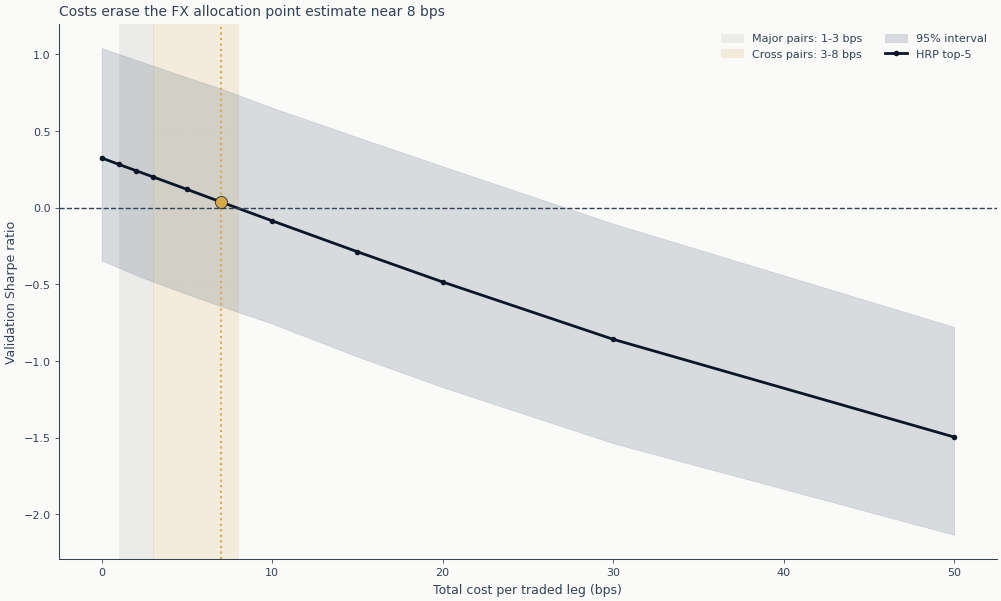

In [14]:
x = cost_rows["cost_bps"].to_numpy()
y = cost_rows["sharpe"].to_numpy()
lower = cost_rows["sharpe_ci95_lo"].to_numpy()
upper = cost_rows["sharpe_ci95_hi"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.axvspan(1, 3, color=COLORS["silver_muted"], alpha=0.8, label="Major pairs: 1-3 bps")
ax.axvspan(3, 8, color=COLORS["amber"], alpha=0.16, label="Cross pairs: 3-8 bps")
ax.fill_between(x, lower, upper, color=COLORS["slate"], alpha=0.15, label="95% interval")
ax.plot(x, y, color=COLORS["blue"], marker="o", linewidth=2, label="HRP top-5")
ax.axhline(0, color=COLORS["neutral"], linewidth=1, linestyle="--")
ax.axvline(configured_cost, color=COLORS["amber"], linewidth=1.5, linestyle=":")
ax.scatter(
    [configured_cost],
    [configured_row["sharpe"]],
    color=COLORS["amber"],
    edgecolor=COLORS["blue"],
    s=75,
    zorder=4,
)
ax.set_xlabel("Total cost per traded leg (bps)")
ax.set_ylabel("Validation Sharpe ratio")
ax.set_title("Costs erase the FX allocation point estimate near 8 bps")
ax.legend(frameon=False, ncol=2)
ax.grid(axis="both", alpha=0.22)
fig.show()

## Key takeaways

1. **The point estimate crosses zero near 7.91 bps.** Sharpe declines monotonically from 0.324
   without costs to 0.037 at 7 bps and -0.086 at 10 bps.
2. **The configured cost sits on the boundary.** The 1-3 bps major-pair band retains a positive
   point estimate; the 3-8 bps cross-pair band reaches the interpolated breakeven.
3. **Cost drag is measurable, but alpha is not.** Removing 7 bps improves paired Sharpe by 0.282
   with interval [0.242, 0.329], while the zero-cost standalone interval still crosses zero.
4. **Execution quality cannot rescue weak evidence.** Cost control preserves more of the small
   allocation estimate, but it does not turn this validation search into a dependable strategy.

**Next:** The risk-management notebook tests whether position controls improve the selected
lineage without adding enough turnover to erase the remaining point estimate.